# 02. Number Systems and Representation

**Part 1: Foundations of Numerical Computing**

## Learning objectives

By the end of this lesson you will be able to:

1. Read any positional number as a **polynomial in its base**, and connect this directly to
   Horner's rule from lesson 01.
2. Convert integers between binary, octal, decimal and hexadecimal in **any** direction.
3. Convert fractions between bases, and explain why that needs repeated **multiplication**
   rather than repeated division.
4. State and prove exactly **which fractions terminate** in a given base.
5. Explain, with a proof rather than a slogan, why `0.1 + 0.2 != 0.3` on every binary
   computer ever built.

## Prerequisites

Lesson 01. Nothing more.

---

## 1. A number is a polynomial

When you write $3705$ in decimal you mean

$$3705 = 3 \cdot 10^3 + 7 \cdot 10^2 + 0 \cdot 10^1 + 5 \cdot 10^0.$$

That is a polynomial in $10$ with coefficients $3, 7, 0, 5$. Nothing about the argument
depends on it being ten.

> **Definition 2.1 (Positional representation).** Let $b \ge 2$ be an integer, the **base**
> or **radix**. A string of digits $d_k d_{k-1} \cdots d_1 d_0 . d_{-1} d_{-2} \cdots$ with
> each $0 \le d_i < b$ represents the number
>
> $$x = \sum_{i=-\infty}^{k} d_i \, b^{\,i}.$$

Two facts follow immediately, and they are the whole of this lesson:

- **Reading a number in base $b$ is evaluating a polynomial at $b$.** So Horner's rule from
  lesson 01 is the right way to do it.
- **Writing a number in base $b$ is finding the coefficients of that polynomial.** Integers
  and fractions need different procedures, because the exponents run in opposite directions.

The bases that matter for us are:

| Base | Name | Digits | Why we care |
|---|---|---|---|
| 2 | binary | 0, 1 | what the hardware actually stores |
| 8 | octal | 0 to 7 | three bits per digit, compact |
| 10 | decimal | 0 to 9 | what humans type and read |
| 16 | hexadecimal | 0 to 9, A to F | four bits per digit, used to print raw bit patterns |

## 2. Reading a number: base to decimal

Apply Horner at the base. For $1101_2$:

$$((1 \cdot 2 + 1) \cdot 2 + 0) \cdot 2 + 1 = ((3) \cdot 2 + 0) \cdot 2 + 1 = 6 \cdot 2 + 1 = 13.$$

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import numbersystems as ns

print("1101 base 2  ->", ns.int_from_base("1101", 2))
print("3705 base 10 ->", ns.int_from_base("3705", 10))
print("FF   base 16 ->", ns.int_from_base("FF", 16))
print("777  base 8  ->", ns.int_from_base("777", 8))

# Cross-check against Python's own base parser.
for s, b in [("1101", 2), ("3705", 10), ("FF", 16), ("777", 8)]:
    assert ns.int_from_base(s, b) == int(s, b)
print("\nall values agree with Python's int(s, base)")

1101 base 2  -> 13
3705 base 10 -> 3705
FF   base 16 -> 255
777  base 8  -> 511

all values agree with Python's int(s, base)


## 3. Writing an integer: repeated division

To find the digits of $n$ in base $b$, divide by $b$ and keep the remainder. The remainder is
the last digit, because every other term in the sum is a multiple of $b$. Repeat on the
quotient.

> **Proposition 2.2.** For integer $n \ge 0$ and base $b \ge 2$, write $n = qb + r$ with
> $0 \le r < b$. Then $r$ is the units digit of $n$ in base $b$, and the remaining digits are
> those of $q$.
>
> *Proof.* Write $n = \sum_{i \ge 0} d_i b^i$. Then
> $n = d_0 + b \sum_{i \ge 1} d_i b^{i-1}$. Since $0 \le d_0 < b$, uniqueness of the
> division algorithm gives $r = d_0$ and $q = \sum_{i \ge 1} d_i b^{i-1}$, whose digits are
> $d_1, d_2, \dots$. $\square$

The procedure terminates because the quotient strictly decreases and stays non-negative.

### Pseudocode

```text
INT_TO_BASE(n, b)
    if n = 0: return "0"
    digits <- empty list
    while n > 0:
        q, r <- divmod(n, b)
        append digit-symbol(r) to digits
        n <- q
    return digits reversed
```

Let us watch the division table for $53$ in binary.

In [3]:
n, base = 53, 2
steps = ns.int_to_base_steps(n, base)

print(f"Converting {n} to base {base} by repeated division:\n")
print(f"{'dividend':>9} {'/':^3} {'base':>4} {'=':^3} {'quotient':>9} "
      f"{'remainder':>10}")
print("-" * 46)
for dividend, quotient, remainder in steps:
    print(f"{dividend:>9} {'/':^3} {base:>4} {'=':^3} {quotient:>9} {remainder:>10}")

digits = "".join(str(r) for _, _, r in reversed(steps))
print(f"\nread the remainders bottom to top: {digits}")
print(f"nalib agrees:                      {ns.int_to_base(n, base)}")
print(f"Python agrees:                     {bin(n)[2:]}")
assert digits == ns.int_to_base(n, base) == bin(n)[2:]

Converting 53 to base 2 by repeated division:

 dividend  /  base  =   quotient  remainder
----------------------------------------------
       53  /     2  =         26          1
       26  /     2  =         13          0
       13  /     2  =          6          1
        6  /     2  =          3          0
        3  /     2  =          1          1
        1  /     2  =          0          1

read the remainders bottom to top: 110101
nalib agrees:                      110101
Python agrees:                     110101


## 4. Writing a fraction: repeated multiplication

For the fractional part the exponents are negative, so division is the wrong move.

If $x = \sum_{i \ge 1} d_{-i} b^{-i}$ with $0 \le x < 1$, then

$$bx = d_{-1} + \sum_{i \ge 2} d_{-i} b^{-i+1},$$

so the **integer part** of $bx$ is the first fractional digit, and the leftover fractional
part carries the rest. Repeat.

### Pseudocode

```text
FRAC_TO_BASE(x, b, ndigits)          # 0 <= x < 1
    digits <- empty list
    repeat ndigits times:
        if x = 0: stop            # the expansion terminated
        y <- b * x
        d <- floor(y)
        append digit-symbol(d) to digits
        x <- y - d
    return digits
```

Note the asymmetry: integers **always** terminate, fractions **may not**. That single fact is
responsible for most of the surprise in floating point arithmetic.

In [4]:
from fractions import Fraction

x = Fraction(1, 10)                 # exactly one tenth, no floating point involved
steps = ns.frac_to_base_steps(x, 2, ndigits=12)

print("Converting 1/10 to binary by repeated multiplication:\n")
print(f"{'value':>12} {'x 2':^5} {'=':^3} {'result':>12} {'digit':>7}")
print("-" * 44)
for before, after, digit in steps:
    print(f"{str(before):>12} {'x 2':^5} {'=':^3} "
          f"{str(digit + after):>12} {digit:>7}")

digits, exact = ns.frac_to_base(x, 2, 12)
print(f"\ndigits so far : 0.{digits}")
print(f"terminated?   : {exact}")

Converting 1/10 to binary by repeated multiplication:

       value  x 2   =        result   digit
--------------------------------------------
        1/10  x 2   =           1/5       0
         1/5  x 2   =           2/5       0
         2/5  x 2   =           4/5       0
         4/5  x 2   =           8/5       1
         3/5  x 2   =           6/5       1
         1/5  x 2   =           2/5       0
         2/5  x 2   =           4/5       0
         4/5  x 2   =           8/5       1
         3/5  x 2   =           6/5       1
         1/5  x 2   =           2/5       0
         2/5  x 2   =           4/5       0
         4/5  x 2   =           8/5       1

digits so far : 0.000110011001
terminated?   : False


Look at the `value` column. It goes $1/10, 1/5, 2/5, 4/5, 3/5, 1/5, \dots$ and then **repeats
forever**. Once a remainder repeats, the digits repeat, and the expansion never terminates.

## 4a. Writing both conversions from scratch

The two procedures are short enough to write out in full, and doing so makes the asymmetry
between them concrete: one loop divides, the other multiplies.

In [5]:
DIGITS = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"      # enough for any base up to 36


def int_to_base_scratch(n, base):
    """Repeated division. Collect remainders, then reverse them.

    Handles any integer: positive, negative and zero, in any base from 2 to 36. The sign is
    split off first, because `divmod` on a negative number floors towards minus infinity and
    would produce digits for a different value.
    """
    if not 2 <= base <= len(DIGITS):
        raise ValueError(f"base must be between 2 and {len(DIGITS)}")
    if n == 0:
        return "0"
    sign = "-" if n < 0 else ""
    n = abs(n)
    out = []
    while n > 0:
        n, r = divmod(n, base)
        out.append(DIGITS[r])
    return sign + "".join(reversed(out))


def frac_to_base_scratch(x, base, ndigits=20):
    """Repeated multiplication. Collect integer parts in the order they appear.

    x must be an exact Fraction, not a float. Using a float here would silently answer a
    different question, since the float is already a rounded value.
    """
    out = []
    for _ in range(ndigits):
        if x == 0:
            return "".join(out) if out else "0", True
        x = x * base
        d = int(x)
        out.append(DIGITS[d])
        x = x - d
    return "".join(out), x == 0


# Check both against nalib over a wide random sample.
rng_local = np.random.default_rng(SEED)
mismatches = 0
for _ in range(2000):
    n = int(rng_local.integers(0, 10**7))
    base = int(rng_local.integers(2, 17))
    if int_to_base_scratch(n, base) != ns.int_to_base(n, base):
        mismatches += 1

    num, den = int(rng_local.integers(0, 999)), int(rng_local.integers(1, 1000))
    frac = Fraction(num, den)
    frac -= int(frac)
    if frac_to_base_scratch(frac, base, 30) != ns.frac_to_base(frac, base, 30):
        mismatches += 1

print(f"disagreements with nalib over 4000 conversions: {mismatches}")
assert mismatches == 0
print("the from-scratch versions and the library agree everywhere")
print()
print(f"53 in base 2  : {int_to_base_scratch(53, 2)}")
print(f"1/10 in base 2: 0.{frac_to_base_scratch(Fraction(1, 10), 2, 16)[0]}...")

disagreements with nalib over 4000 conversions: 0
the from-scratch versions and the library agree everywhere

53 in base 2  : 110101
1/10 in base 2: 0.0001100110011001...


## 5. Which fractions terminate?

This is not a quirk of one tenth. There is a clean theorem.

> **Theorem 2.3 (Terminating expansions).** Let $p/q$ be a fraction in lowest terms with
> $q > 0$. Its expansion in base $b$ terminates if and only if every prime factor of $q$ also
> divides $b$.
>
> *Proof.* ($\Leftarrow$) If every prime of $q$ divides $b$, then $q \mid b^m$ for some $m$,
> so $p/q = (p b^m / q) / b^m$ where the numerator is an integer. A number of the form
> $N / b^m$ has a terminating base-$b$ expansion, namely the digits of $N$ shifted $m$ places.
>
> ($\Rightarrow$) If the expansion terminates after $m$ digits then $p/q = N/b^m$ for some
> integer $N$, so $p b^m = N q$, giving $q \mid p b^m$. Since $\gcd(p, q) = 1$ we get
> $q \mid b^m$, so every prime of $q$ divides $b$. $\square$

Now everything is explained.

- **Base 10** has primes $\{2, 5\}$. So $1/10$ terminates, and so do $1/2$, $1/4$, $1/5$,
  $1/20$. But $1/3$ does not.
- **Base 2** has the single prime $\{2\}$. So only fractions whose denominator is a power of
  two terminate. $1/2$, $1/4$, $1/8$ are fine. $1/10$ is not, because $10 = 2 \cdot 5$ and
  $5 \nmid 2$.

**A binary computer cannot store one tenth exactly.** Not through poor design, but because
$5$ is not a power of $2$.

In [6]:
tests = [Fraction(1, 2), Fraction(1, 4), Fraction(3, 8), Fraction(1, 5),
         Fraction(1, 10), Fraction(1, 3), Fraction(7, 100)]

print(f"{'fraction':>10} {'base 10':>9} {'base 2':>8}   {'binary expansion':<28}")
print("-" * 62)
for f in tests:
    in10 = ns.is_exact_in_base(f, 10)
    in2 = ns.is_exact_in_base(f, 2)
    expansion = ns.to_base(f, 2, 20)
    print(f"{str(f):>10} {str(in10):>9} {str(in2):>8}   {expansion:<28}")

# The theorem, checked directly: terminating in base 2 means a power-of-two denominator.
for f in tests:
    q = f.denominator
    power_of_two = (q & (q - 1)) == 0
    assert ns.is_exact_in_base(f, 2) == power_of_two, f
print("\ntheorem confirmed: terminates in base 2 exactly when the denominator is a power of 2")

  fraction   base 10   base 2   binary expansion            
--------------------------------------------------------------
       1/2      True     True   0.1                         
       1/4      True     True   0.01                        
       3/8      True     True   0.011                       
       1/5      True    False   0.00110011001100110011...   
      1/10      True    False   0.00011001100110011001...   
       1/3     False    False   0.01010101010101010101...   
     7/100      True    False   0.00010001111010111000...   

theorem confirmed: terminates in base 2 exactly when the denominator is a power of 2


### Seeing the theorem

Theorem 2.3 says the answer depends only on which **primes** divide the base. Plotting which
fractions terminate makes that visible at a glance.

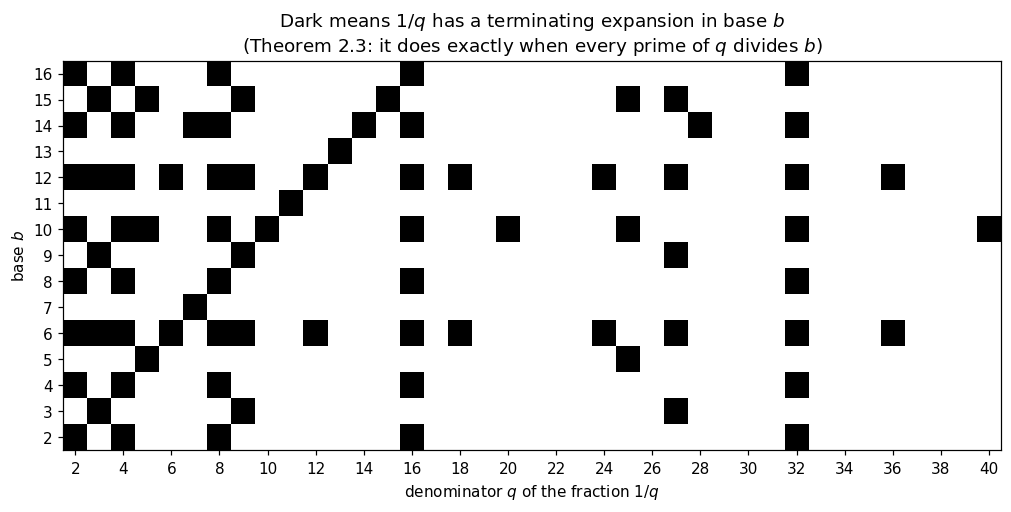

how many of the 39 fractions 1/2 ... 1/40 terminate, by base:
  base  2 (primes [2]) : 5
  base  4 (primes [2]) : 5
  base  8 (primes [2]) : 5
  base 16 (primes [2]) : 5
  base  3 (primes [3]) : 3
  base  9 (primes [3]) : 3
  base  6 (primes [2, 3]) : 13
  base 12 (primes [2, 3]) : 13
  base 10 (primes [2, 5]) : 10
  base 15 (primes [3, 5]) : 6

bases 2, 4, 8 and 16 give IDENTICAL rows, and so do 3 and 9, and 6 and 12.
only the set of prime factors matters, exactly as the theorem says.


In [7]:
bases = np.arange(2, 17)
denoms = np.arange(2, 41)

grid = np.zeros((len(bases), len(denoms)))
for i, b in enumerate(bases):
    for j, q in enumerate(denoms):
        grid[i, j] = 1.0 if ns.is_exact_in_base(Fraction(1, int(q)), int(b)) else 0.0

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.imshow(grid, aspect="auto", cmap="Greys", origin="lower",
          extent=[denoms[0] - 0.5, denoms[-1] + 0.5, bases[0] - 0.5, bases[-1] + 0.5])
ax.set_xticks(denoms[::2])
ax.set_yticks(bases)
ax.set_xlabel("denominator $q$ of the fraction $1/q$")
ax.set_ylabel("base $b$")
ax.set_title("Dark means $1/q$ has a terminating expansion in base $b$\n"
             "(Theorem 2.3: it does exactly when every prime of $q$ divides $b$)")
ax.grid(False)
plt.show()

def prime_factors(n):
    """The distinct primes dividing n, by trial division.

    Defined for n >= 1. n = 1 has no prime factors, so the answer is the empty list. Zero and
    negative numbers have no factorization into primes in the usual sense, so they are
    rejected rather than silently returning nothing.
    """
    n = int(n)
    if n < 1:
        raise ValueError("prime_factors needs a positive integer")
    out, d = [], 2
    while d * d <= n:
        if n % d == 0:
            out.append(d)
            while n % d == 0:
                n //= d
        d += 1
    if n > 1:
        out.append(n)
    return out


counts = {int(b): int(grid[i].sum()) for i, b in enumerate(bases)}
print(f"how many of the {len(denoms)} fractions 1/2 ... 1/40 terminate, by base:")
for b in [2, 4, 8, 16, 3, 9, 6, 12, 10, 15]:
    print(f"  base {b:>2} (primes {prime_factors(b)}) : {counts[b]}")

# Bases with the same prime set must give identical rows.
for b1, b2 in [(2, 4), (2, 8), (2, 16), (4, 8), (3, 9), (6, 12)]:
    i1, i2 = list(bases).index(b1), list(bases).index(b2)
    assert np.array_equal(grid[i1], grid[i2]), (b1, b2)
print("\nbases 2, 4, 8 and 16 give IDENTICAL rows, and so do 3 and 9, and 6 and 12.")
print("only the set of prime factors matters, exactly as the theorem says.")

**What to take from this.** Base 16 is no better than base 2 for representing fractions, because
they share the single prime 2. Base 12 does noticeably better than base 10 despite being close
in size, because $12 = 2^2 \cdot 3$ brings in the prime 3 while $10 = 2 \cdot 5$ brings in 5,
and small denominators are far more likely to contain a factor of 3 than a factor of 5.

## 6. The binary, octal and hexadecimal shortcut

Because $8 = 2^3$ and $16 = 2^4$, converting between these bases needs no arithmetic at all.
Group the bits.

$$\underbrace{1011}_{\text{B}}\ \underbrace{0110}_{6} \; = \; \text{B6}_{16},
\qquad
\underbrace{101}_{5}\ \underbrace{101}_{5}\ \underbrace{10}_{2}\ \dots$$

Group in threes for octal, in fours for hexadecimal, starting **from the binary point** and
working outwards in both directions.

In [8]:
value = 0b10110110          # one byte

print(f"binary      : {ns.int_to_base(value, 2)}")
print(f"grouped by 4: {' '.join(['1011', '0110'])}")
print(f"hexadecimal : {ns.int_to_base(value, 16)}")
print()
print(f"grouped by 3: {' '.join(['10', '110', '110'])}")
print(f"octal       : {ns.int_to_base(value, 8)}")

assert ns.int_to_base(value, 16) == "B6"
assert ns.int_to_base(value, 8) == "266"
print("\nthis is why raw memory is printed in hex: one hex digit is exactly four bits")

binary      : 10110110
grouped by 4: 1011 0110
hexadecimal : B6

grouped by 3: 10 110 110
octal       : 266

this is why raw memory is printed in hex: one hex digit is exactly four bits


## 7. Converting between any two bases

The safe route between two bases is always **through an exact rational**, never through a
float. `nalib.numbersystems.convert` does exactly that.

In [9]:
cases = [("FF", 16, 2), ("266", 8, 16), ("1101.101", 2, 10),
         ("0.1", 10, 2), ("0.1", 10, 8), ("0.1", 10, 16), ("3705", 10, 2)]

print(f"{'input':>12} {'from':>5} {'to':>4}   {'result'}")
print("-" * 60)
for s, bf, bt in cases:
    print(f"{s:>12} {bf:>5} {bt:>4}   {ns.convert(s, bf, bt, 16)}")

       input  from   to   result
------------------------------------------------------------
          FF    16    2   11111111
         266     8   16   B6
    1101.101     2   10   13.625
         0.1    10    2   0.0001100110011001...
         0.1    10    8   0.0631463146314631...
         0.1    10   16   0.1999999999999999...
        3705    10    2   111001111001


Notice the last three lines about one tenth. It terminates in base 10, does not terminate in
base 2, does not terminate in base 8, and does not terminate in base 16. All three of those
bases have only the prime 2, so Theorem 2.3 says exactly this.

### Round trip check

A conversion routine that cannot come back is not trustworthy. Let us push a few thousand
random rationals out and back.

In [10]:
rng_local = np.random.default_rng(SEED)
bad = 0
checked = 0

for _ in range(3000):
    num = int(rng_local.integers(0, 10_000))
    den = int(rng_local.integers(1, 1_000))
    f = Fraction(num, den)
    for base in (2, 3, 8, 10, 16):
        if not ns.is_exact_in_base(f, base):
            continue                       # only round-trip what can be written exactly
        text = ns.to_base(f, base, 64)
        back = ns.from_base(text, base)
        checked += 1
        if back != f:
            bad += 1

print(f"exact round trips checked : {checked}")
print(f"failures                  : {bad}")
assert bad == 0
print("every terminating value survived the round trip exactly, as a Fraction")

exact round trips checked : 457
failures                  : 0
every terminating value survived the round trip exactly, as a Fraction


## 8. Why `0.1 + 0.2 != 0.3`

We now have everything needed to explain the most famous complaint about computer arithmetic,
and to explain it properly rather than with a shrug.

In [11]:
print(f"0.1 + 0.2      = {0.1 + 0.2!r}")
print(f"0.3            = {0.3!r}")
print(f"are they equal? {0.1 + 0.2 == 0.3}")

0.1 + 0.2      = 0.30000000000000004
0.3            = 0.3
are they equal? False


Here is what is actually going on. Python's `float` is IEEE double precision, which stores a
binary fraction with 53 significant bits. When you type `0.1`, the machine cannot store one
tenth, so it stores **the nearest double to one tenth**. `Fraction` lets us see that stored
value exactly.

In [12]:
stored_01 = Fraction(0.1)          # the exact value of the double named 0.1
stored_02 = Fraction(0.2)
stored_03 = Fraction(0.3)

print("what the machine actually stores, as exact fractions:\n")
print(f"0.1 -> {stored_01}")
print(f"       = {float(stored_01):.20f}")
print()
print(f"0.2 -> {stored_02}")
print(f"       = {float(stored_02):.20f}")
print()
print(f"0.3 -> {stored_03}")
print(f"       = {float(stored_03):.20f}")

print(f"\nis the stored 0.1 exactly one tenth? {stored_01 == Fraction(1, 10)}")
print(f"error in storing 0.1: {float(stored_01 - Fraction(1, 10)):.3e}")

what the machine actually stores, as exact fractions:

0.1 -> 3602879701896397/36028797018963968
       = 0.10000000000000000555

0.2 -> 3602879701896397/18014398509481984
       = 0.20000000000000001110

0.3 -> 5404319552844595/18014398509481984
       = 0.29999999999999998890

is the stored 0.1 exactly one tenth? False
error in storing 0.1: 5.551e-18


Now add the two stored values **exactly**, and compare with the stored value of `0.3`:

In [13]:
exact_sum = stored_01 + stored_02

print(f"stored(0.1) + stored(0.2) exactly = {exact_sum}")
print(f"stored(0.3)                       = {stored_03}")
print(f"equal? {exact_sum == stored_03}")
print(f"\ndifference = {exact_sum - stored_03}")
print(f"           = {float(exact_sum - stored_03):.3e}")

assert exact_sum != stored_03
print("\nSo the sum is not wrong. The three inputs were already not the numbers you")
print("asked for, and the two roundings did not happen to land in the same place.")

stored(0.1) + stored(0.2) exactly = 10808639105689191/36028797018963968
stored(0.3)                       = 5404319552844595/18014398509481984
equal? False

difference = 1/36028797018963968
           = 2.776e-17

So the sum is not wrong. The three inputs were already not the numbers you
asked for, and the two roundings did not happen to land in the same place.


Look at the binary expansions and the reason is visible directly:

In [14]:
for name, val in [("1/10 exactly", Fraction(1, 10)),
                  ("2/10 exactly", Fraction(2, 10)),
                  ("3/10 exactly", Fraction(3, 10))]:
    print(f"{name:>14}  =  {ns.to_base(val, 2, 40)}")

print()
print("all three repeat forever with the pattern 0011.")
print("double precision keeps 53 significant bits and rounds the rest away.")
print("rounding three different infinite expansions need not stay consistent.")

  1/10 exactly  =  0.0001100110011001100110011001100110011001...
  2/10 exactly  =  0.0011001100110011001100110011001100110011...
  3/10 exactly  =  0.0100110011001100110011001100110011001100...

all three repeat forever with the pattern 0011.
double precision keeps 53 significant bits and rounds the rest away.
rounding three different infinite expansions need not stay consistent.


**The point.** This is not a bug, and it is not floating point being sloppy. It is
Theorem 2.3. One tenth has no finite binary expansion, so no binary machine of any precision
can hold it. The consequence for how you write code is simple and it applies for the rest of
your career:

> Never compare floating point numbers with `==`. Compare with a tolerance.

Lesson 04 makes "a tolerance" precise, and lesson 06 explains how to choose one.

## 9. A useful sanity habit

Because `0.1` is really `0.1000000000000000055511151231257827021181583404541015625`, printing
17 digits of a double shows you the stored value, and printing fewer hides it. Python's
`repr` prints the **shortest string that round-trips**, which is friendly but can conceal
what is really there.

In [15]:
x = 0.1
print(f"repr           : {x!r}")
print(f"20 decimals    : {x:.20f}")
print(f"exact fraction : {Fraction(x)}")
print(f"exact in binary: {ns.to_base(Fraction(x), 2, 60)}")
print()
print("all four lines describe the same single stored number.")

repr           : 0.1
20 decimals    : 0.10000000000000000555
exact fraction : 3602879701896397/36028797018963968
exact in binary: 0.0001100110011001100110011001100110011001100110011001101

all four lines describe the same single stored number.


## 10. Complexity

| Operation | Cost | Note |
|---|---|---|
| Read $n$ digits in base $b$ (Horner) | $O(n)$ | one multiply and one add per digit |
| Write an integer $N$ in base $b$ | $O(\log_b N)$ | one division per digit produced |
| Write a fraction to $m$ digits | $O(m)$ | one multiplication per digit |
| Binary to octal or hexadecimal | $O(n)$, no arithmetic | pure regrouping of bits |

Working with exact `Fraction` objects costs more than floats, because the numerators and
denominators grow. That is the price of exactness, and it is exactly why hardware uses
floating point instead. Lesson 03 takes up that trade.

## 11. Common mistakes

1. **Using division for the fractional part.** Integers use repeated division, fractions use
   repeated multiplication. Mixing them up is the most common error in this topic.
2. **Rounding the truncated digits.** When you cut off a non-terminating expansion, say so.
   `nalib` prints a trailing `...` for exactly this reason.
3. **Demonstrating exactness with floats.** Writing `0.1` in Python to prove something about
   one tenth is circular: you have already lost the value. Use `Fraction`.
4. **Assuming hexadecimal is somehow more accurate.** It is a different way of writing the
   same bits. Base 16 has only the prime 2, so it terminates on exactly the same set of
   fractions as base 2.

## 12. Exercises

**Level 1, conceptual**

1.1 Explain in one sentence why integer conversion always terminates but fractional
conversion may not.

1.2 Does $1/3$ terminate in base 3? In base 6? In base 12? Answer using Theorem 2.3, then
check with `nalib.numbersystems.is_exact_in_base`.

1.3 Why is hexadecimal used to print memory contents rather than base 10?

**Level 2, mathematical**

2.1 Prove that in base $b$, the expansion of $p/q$ (in lowest terms) is eventually periodic
with period dividing the multiplicative order of $b$ modulo $q'$, where $q'$ is $q$ with all
factors shared with $b$ removed.

2.2 Show that $0.\overline{0011}_2$ (the repeating block 0011) equals exactly $1/10$. Use the
geometric series.

2.3 How many fractions with denominator at most 100 terminate in base 2? Derive the count,
then verify it by enumeration.

**Level 3, computational**

3.1 Write `to_base` yourself for integers and fractions, without looking at `nalib`. Test it
against `nalib.numbersystems.to_base` on 1000 random rationals.

3.2 Write a function that detects the repeating block in a non-terminating expansion and
returns it, for example `(0, "0011")` for $1/10$ in base 2. Use the fact that the expansion
repeats exactly when a remainder repeats.

**Level 4, experimental**

4.1 For each base from 2 to 16, count how many of the fractions $1/q$ for $q = 2 \dots 100$
terminate. Plot the count against the base. Explain the pattern in terms of the prime
factorisation of the base.

4.2 Measure how the run time of `Fraction` arithmetic grows as you add up $1/1 + 1/2 + \cdots
+ 1/n$ exactly, for $n$ up to a few thousand. Compare against the same sum in floating point.
What is the cost of exactness?

**Level 5, advanced**

5.1 Base 3 with digits $\{-1, 0, 1\}$ is called balanced ternary. It needs no separate sign.
Implement conversion to and from balanced ternary, and describe one arithmetic operation that
becomes simpler in it.

5.2 Decimal floating point (IEEE 754-2008) uses base 10 and so stores $0.1$ exactly. Why did
binary win for general computing anyway? Consider hardware cost, the density of representable
numbers, and where decimal arithmetic is actually required by law.

Solutions are in [`solutions/part01_foundations.md`](../solutions/part01_foundations.md).

## 13. Key takeaways

- A number in base $b$ **is** a polynomial in $b$. Reading one is Horner's rule.
- Integers convert by **repeated division**, fractions by **repeated multiplication**.
- **Theorem 2.3**: $p/q$ terminates in base $b$ exactly when every prime factor of $q$
  divides $b$.
- Base 2 has only the prime 2, so a binary machine stores exactly those fractions whose
  denominator is a power of two. One tenth is not one of them.
- `0.1 + 0.2 != 0.3` is a direct consequence, not a defect. The inputs were already rounded
  before any addition happened.
- Never test floating point values with `==`.

## Where this goes next

Lesson 03 takes these binary fractions and packs them into the fixed number of bits that
hardware provides. That is IEEE 754, and it introduces the two limits that shape everything
after it: finitely many **digits** of precision, and a finite **range** of exponents.

---

*Sources: Sauer, Numerical Analysis 3rd ed., section 0.2; Gupta, Numerical Methods,
chapter 1 (sections 1.2 and 1.3). Theorem 2.3 and its proof are standard and are stated here
to give the books' conversion procedures a firm reason to work.*